In [2]:
# Optimized Bagging Regressor using GridSearchCV on California Housing dataset

In [3]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing()
X = data.data
y = data.target

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)

## APPLYING RANDOM SEARCH CV

In [6]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [10, 50, 100, 200],
    "max_depth": [3, 5, 10, None],
    "max_features": [0.5, 0.8, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Random Search Best Params:", random_search.best_params_)
print("Random Search Best Score:", random_search.best_score_)

Random Search Best Params: {'n_estimators': 50, 'max_features': 0.5, 'max_depth': None}
Random Search Best Score: 0.8111698306855881


## APPLYING GRID SEARCH CV

In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [10,20,40,50,60,80, 100],
    "max_depth": [5, 10],
    "max_features": [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=model,                  ## MODEL THAT I TUNED
    param_grid=param_grid,            ## All combination test
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Grid Search Best Params:", grid_search.best_params_)
print("Grid Search Best Score:", grid_search.best_score_)

Grid Search Best Params: {'max_depth': 10, 'max_features': 0.8, 'n_estimators': 100}
Grid Search Best Score: 0.7827879138011018


In [15]:
from sklearn.metrics import r2_score

# Random Search model
y_pred_random = random_search.best_estimator_.predict(X_test)

# Grid Search model
y_pred_grid = grid_search.best_estimator_.predict(X_test)

print("Random Search Test R2:", r2_score(y_test, y_pred_random))
print("Grid Search Test R2:", r2_score(y_test, y_pred_grid))

Random Search Test R2: 0.8064788375497507
Grid Search Test R2: 0.7743878335875616


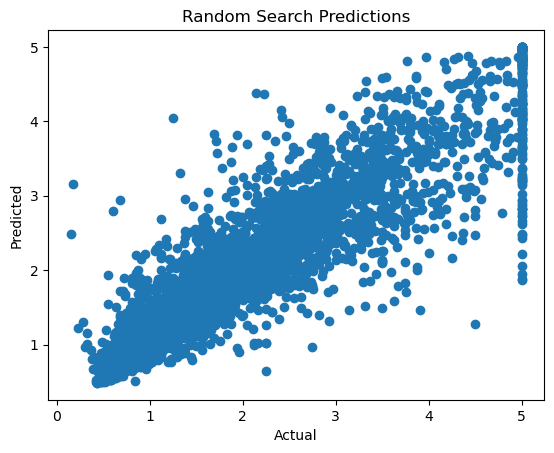

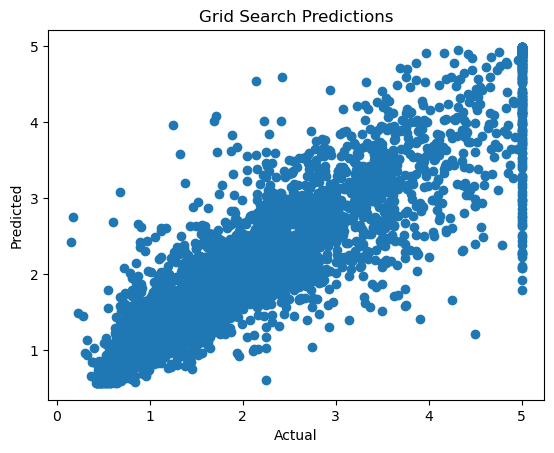

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred_random)
plt.title("Random Search Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

plt.figure()
plt.scatter(y_test, y_pred_grid)
plt.title("Grid Search Predictions")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

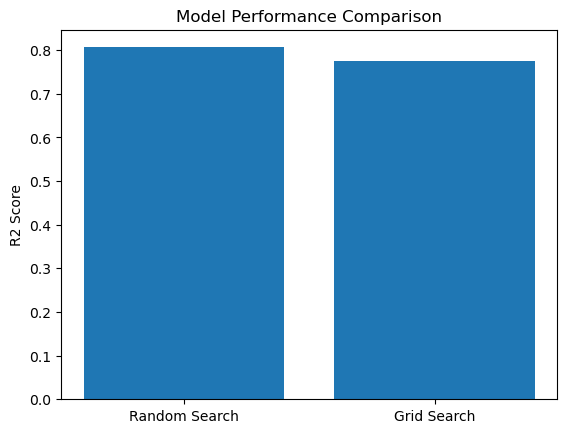

In [17]:
scores = [
    r2_score(y_test, y_pred_random),
    r2_score(y_test, y_pred_grid)
]

labels = ["Random Search", "Grid Search"]

plt.figure()
plt.bar(labels, scores)
plt.title("Model Performance Comparison")
plt.ylabel("R2 Score")
plt.show()